In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
draft_url = "https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv"
draft = pd.read_csv(draft_url)

In [6]:
player_stats_url = "https://github.com/nflverse/nflverse-data/releases/download/player_stats/player_stats.csv"
player_stats = pd.read_csv(player_stats_url)

In [35]:
contracts_url = "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz"
contracts = pd.read_csv(contracts_url)

In [38]:
contracts.shape

(31893, 24)

In [39]:
contracts.columns

Index(['player', 'position', 'team', 'is_active', 'year_signed', 'years',
       'value', 'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value',
       'inflated_apy', 'inflated_guaranteed', 'player_page', 'otc_id',
       'date_of_birth', 'height', 'weight', 'college', 'draft_year',
       'draft_round', 'draft_overall', 'draft_team', 'season_history'],
      dtype='object')

In [40]:
contracts.head()

,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,...,otc_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,season_history
0,Aaron Rodgers,QB,Packers,True,2022,5.0,150815000,50271667,150665000,0.241,...,1085,NaN,"6'2""",225.0,California,2005.0,1.0,24.0,Packers,NaN
1,Josh Allen,QB,Bills,True,2021,6.0,258000000,43000000,150000000,0.236,...,6892,NaN,"6'5""",233.0,Wyoming,2018.0,1.0,7.0,Bills,NaN
2,Patrick Mahomes,QB,Chiefs,True,2020,10.0,450000000,45000000,141000000,0.227,...,5594,NaN,"6'2""",225.0,Texas Tech,2017.0,1.0,10.0,Chiefs,NaN
3,Deshaun Watson,QB,Browns,True,2022,5.0,230000000,46000000,230000000,0.221,...,5596,NaN,"6'2""",221.0,Clemson,2017.0,1.0,12.0,Texans,NaN
4,Dak Prescott,QB,Cowboys,True,2021,4.0,160000000,40000000,126000000,0.219,...,4848,NaN,"6'2""",226.0,Mississippi State,2016.0,4.0,135.0,Cowboys,NaN


In [78]:
draft = draft[(draft["season"] >= 2000) & (draft["season"] <= 2020)]
draft = draft[draft['w_av'].notna()]

In [27]:
draft.describe()

,season,round,pick,age,to,allpro,probowls,seasons_started,w_av,car_av,...,pass_ints,rush_atts,rush_yards,rush_tds,receptions,rec_yards,rec_tds,def_solo_tackles,def_ints,def_sacks
count,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,0.0,...,4835.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,4836.000000,3449.000000,1208.000000,1593.000000
mean,2010.120968,4.019231,120.907775,22.489661,2015.227667,0.096154,0.394748,2.386890,19.185897,NaN,...,1.643226,49.457403,210.385236,1.552936,36.916460,423.553350,2.594293,111.187011,6.329470,12.996861
std,6.061905,1.987511,72.438020,0.907111,6.677632,0.508519,1.293323,3.133405,22.440609,NaN,...,13.011465,232.950196,1011.178198,7.855461,115.261272,1430.542666,9.388875,157.548647,7.462076,20.600897
min,2000.000000,1.000000,1.000000,20.000000,2000.000000,0.000000,0.000000,0.000000,-4.000000,NaN,...,0.000000,0.000000,-30.000000,0.000000,0.000000,-20.000000,0.000000,1.000000,1.000000,0.500000
25%,2005.000000,2.000000,58.000000,22.000000,2010.000000,0.000000,0.000000,0.000000,2.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,2.000000
50%,2010.000000,4.000000,117.500000,22.000000,2015.000000,0.000000,0.000000,1.000000,11.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,3.000000,5.000000
75%,2015.000000,6.000000,182.000000,23.000000,2021.000000,0.000000,0.000000,4.000000,29.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,2.000000,16.250000,0.000000,165.000000,8.000000,14.000000
max,2020.000000,7.000000,261.000000,29.000000,2025.000000,8.000000,15.000000,21.000000,184.000000,NaN,...,244.000000,3735.000000,16000.000000,145.000000,1432.000000,17492.000000,121.000000,1172.000000,64.000000,159.500000


In [29]:
draft.columns

Index(['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks'],
      dtype='object')

In [48]:
draft['position'].value_counts()

position
DB     709
WR     607
LB     536
DE     432
DT     395
RB     395
T      366
TE     283
G      258
QB     206
CB     162
C      115
S      115
OLB     62
FB      44
K       42
P       39
ILB     32
OL      17
NT      13
LS       5
DL       3
Name: count, dtype: int64

In [69]:
position_order = ['DB', 'WR', 'LB', 'DE', 'DT', 'RB', 'T', 'TE', 'G', 'QB', 'CB', 'C', 'S', 'OLB', 'FB',
                  'K', 'P', 'ILB', 'OL', 'NT', 'LS', 'DL']

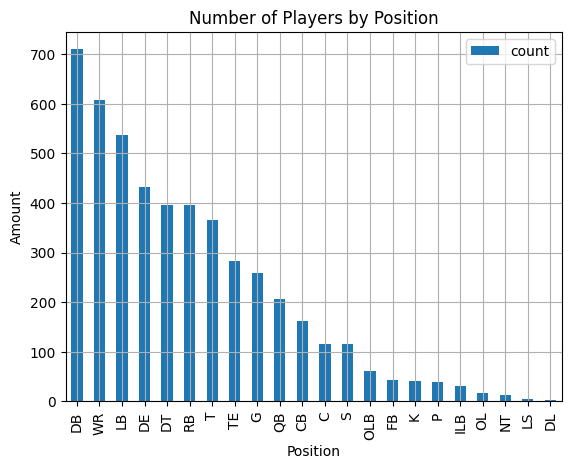

In [70]:
pos_counts = pd.DataFrame(draft['position'].value_counts())

pos_counts = pos_counts.reindex(position_order)

pos_counts.plot.bar(
    title='Number of Players by Position',
    xlabel='Position',
    ylabel='Amount',
    grid=True,
)

plt.show()

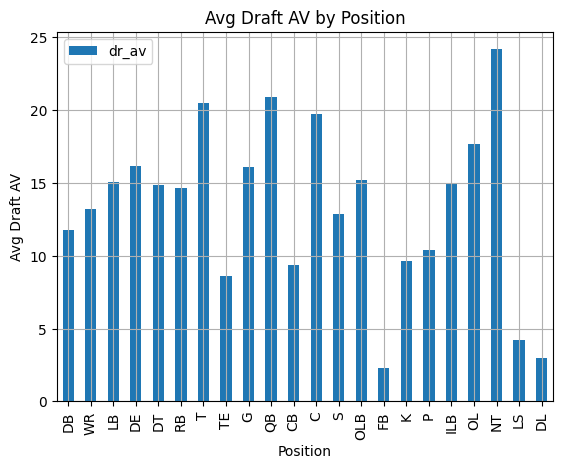

In [71]:
pos_avg_dr_av = pd.DataFrame(draft.groupby('position')['dr_av'].mean())

pos_avg_dr_av = pos_avg_dr_av.reindex(position_order)

pos_avg_dr_av.plot.bar(
    title='Avg Draft AV by Position',
    xlabel='Position',
    ylabel='Avg Draft AV',
    grid=True,
)

plt.show()

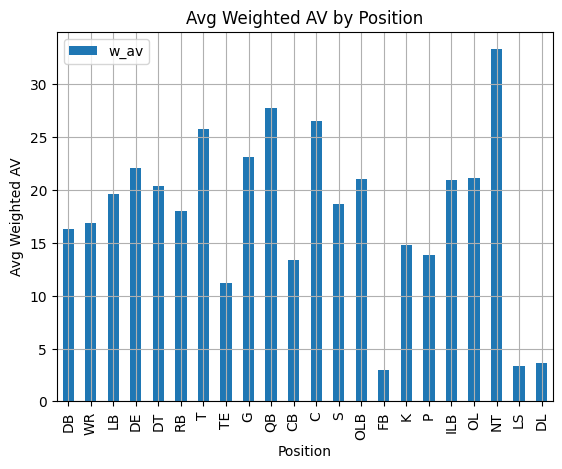

In [ ]:
pos_w_av = pd.DataFrame(draft.groupby('position')['w_av'].mean())

pos_w_av = pos_w_av.reindex(position_order)

pos_w_av.plot.bar(
    title='Avg Weighted AV by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.show()

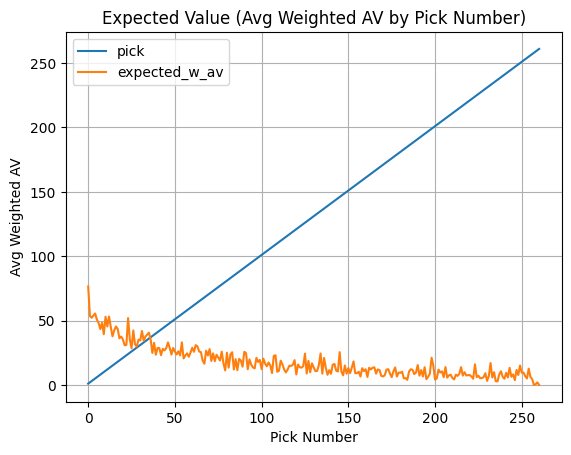

In [80]:
expected = pd.DataFrame(draft.groupby("pick")["w_av"].mean().reset_index().rename(columns={"w_av": "expected_w_av"}))

expected.plot.line(
    title='Expected Value (Avg Weighted AV by Pick Number)',
    xlabel='Pick Number',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.show()

In [81]:
draft = draft.merge(expected, on='pick')

In [82]:
expected.columns

Index(['pick', 'expected_w_av'], dtype='object')

In [83]:
draft.columns

Index(['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks', 'expected_w_av'],
      dtype='object')

In [86]:
draft['ev_delta'] = draft['w_av'] - draft['expected_w_av']

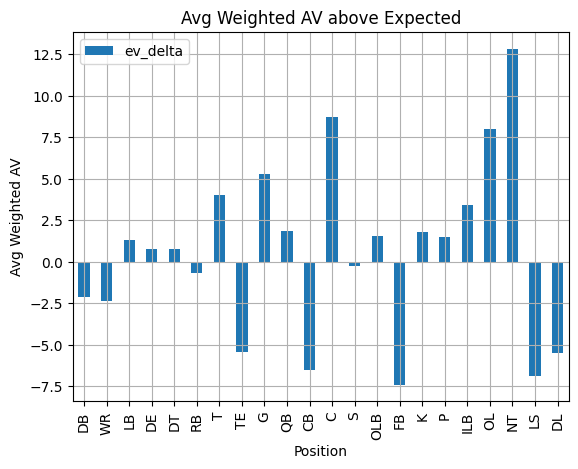

In [87]:
pos_ev_delta = pd.DataFrame(draft.groupby('position')['ev_delta'].mean())

pos_ev_delta = pos_ev_delta.reindex(position_order)

pos_ev_delta.plot.bar(
    title='Avg Weighted AV above Expected',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.show()